In [1]:
!pip install labelme opencv-python albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.9/769.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.1/175.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.1/80.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.4/272.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 995.9/995.9 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing 

In [4]:
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uuid
import cv2

In [5]:
IMAGES_PATH = os.path.join('data', 'images')
number_images = 30

In [8]:
from google.colab.output import eval_js
from IPython.display import display, Javascript
import base64
display(Javascript("""
async function collectImages(numberImages) {
    const video = document.createElement('video');
    const stream = await navigator.mediaDevices.getUserMedia({
        video: true
    });

    video.srcObject = stream;
    video.setAttribute('playsinline', '');
    video.style.width = '500px';
    document.body.appendChild(video);
    await video.play();
    const canvas = document.createElement('canvas');
    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    let images = [];
    for (let i = 0; i < numberImages; i++) {
        const context = canvas.getContext('2d');
        context.drawImage(video, 0, 0);
        images.push(canvas.toDataURL('image/jpeg', 0.8));
        await new Promise(resolve => setTimeout(resolve, 500));
    }

    stream.getTracks().forEach(track => track.stop());
    video.remove();

    return images;
}
"""))

images = eval_js(f"collectImages({number_images})")

for imgnum, image in enumerate(images):
    print('Collecting image{}'.format(imgnum))

    binary = base64.b64decode(image.split(',')[1])

    frame = cv2.imdecode(
        np.frombuffer(binary, dtype=np.uint8),
        cv2.IMREAD_COLOR
    )

    imgname = os.path.join(
        IMAGES_PATH,
        f'{str(uuid.uuid1())}.jpg'
    )

    cv2.imwrite(imgname, frame)

    time.sleep(0.5)

print("Done!")

<IPython.core.display.Javascript object>

Done!


Reviewing dataset and building iamge loading function


In [6]:
import tensorflow as tf
import json

In [7]:
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

In [8]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

In [10]:
images = tf.data.Dataset.list_files('data/images/*.jpg', shuffle=False)

In [11]:
images.as_numpy_iterator().next()

b'data/images/10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.jpg'

In [12]:
def load_image(x):
  byte_img = tf.io.read_file(x)
  img = tf.io.decode_jpeg(byte_img)
  return img

In [13]:
images = images.map(load_image)

array([[[215, 222, 232],
        [216, 223, 233],
        [216, 223, 233],
        ...,
        [204, 205, 209],
        [201, 202, 206],
        [200, 201, 205]],

       [[217, 224, 234],
        [217, 224, 234],
        [217, 224, 234],
        ...,
        [204, 205, 209],
        [202, 203, 207],
        [201, 202, 206]],

       [[218, 225, 235],
        [218, 225, 235],
        [217, 224, 234],
        ...,
        [203, 204, 208],
        [203, 204, 208],
        [203, 204, 208]],

       ...,

       [[ 75,  74,  88],
        [ 77,  76,  90],
        [ 83,  83,  95],
        ...,
        [106,  79,  88],
        [107,  80,  89],
        [110,  83,  92]],

       [[ 87,  85,  99],
        [ 93,  91, 105],
        [103, 101, 114],
        ...,
        [107,  79,  91],
        [109,  81,  93],
        [114,  86,  98]],

       [[ 88,  86, 100],
        [ 99,  97, 111],
        [112, 110, 123],
        ...,
        [109,  81,  93],
        [113,  85,  97],
        [119,  91, 103]]], dtype=uint8)
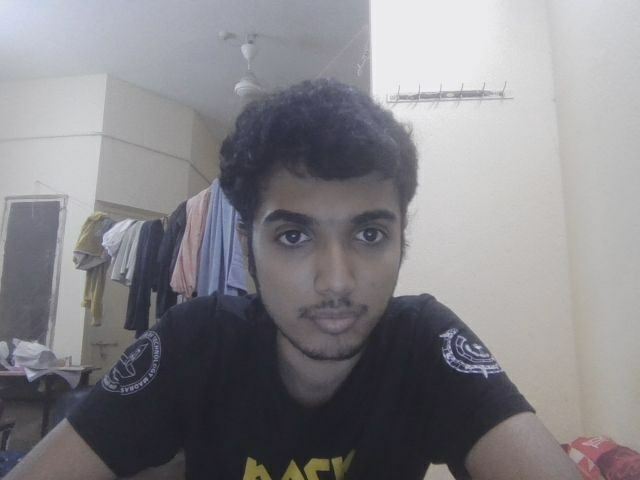

In [14]:
images.as_numpy_iterator().next()

In [15]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

In [16]:
image_generator = images.batch(4).as_numpy_iterator()#gives images in batch of 4

In [19]:
plot_images = image_generator.next()

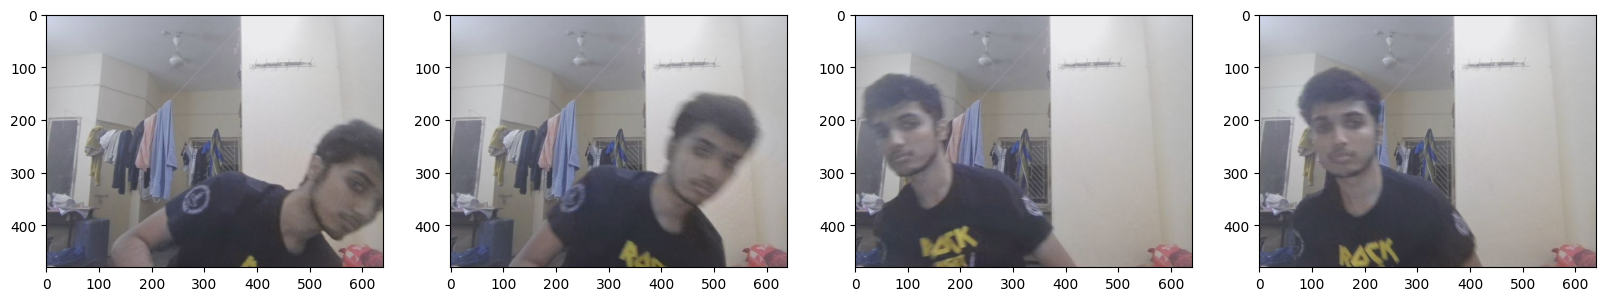

In [20]:
fig, ax = plt.subplots(ncols=4, figsize =(20,20))
for idx, image in enumerate(plot_images):
  ax[idx].imshow(image)

plt.show()


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r data "/content/drive/MyDrive/FaceDetection/" #for storing in drive

cp: cannot stat 'data': No such file or directory


In [3]:
!cp -r "/content/drive/MyDrive/FaceDetection/data" /content/

In [21]:
#Split data(70% to train and 30% to test and val)
!rm -rf /content/data

In [22]:
!cp -r "/content/drive/MyDrive/FaceDetection/data" /content/

In [23]:
!ls /content/data/train/images | wc -l

63


In [24]:
!ls /content/data/images | wc -l

0


In [25]:
for folder in ['train', 'test', 'val']:
  for file in os.listdir(os.path.join('data', folder, 'images')):

    filename = file.split('.')[0] + '.json'
    existing_filepath = os.path.join('data', 'labels', filename)
    if os.path.exists(existing_filepath):
      new_filepath = os.path.join('data', folder, 'labels', filename)
      os.replace(existing_filepath, new_filepath)

In [29]:
img = cv2.imread(os.path.join('data', 'train', 'images', '/content/data/train/images/10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.jpg'))

In [30]:
img.shape

(480, 640, 3)

In [26]:
import albumentations as alb

In [28]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height = 450),
                         alb.HorizontalFlip(p=0.5),
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2),
                         alb.RGBShift(p=0.2),
                         alb.VerticalFlip(p=0.5)],
                        bbox_params = alb.BboxParams(format='albumentations', label_fields=['class_labels']))

In [52]:
img = cv2.imread(os.path.join('data', 'train', 'images', '10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.jpg'))

array([[[233, 223, 216],
        [233, 223, 216],
        [233, 223, 216],
        ...,
        [209, 205, 204],
        [207, 203, 202],
        [206, 202, 201]],

       [[234, 224, 217],
        [234, 224, 217],
        [234, 224, 217],
        ...,
        [209, 205, 204],
        [208, 204, 203],
        [207, 203, 202]],

       [[235, 225, 218],
        [235, 225, 218],
        [235, 225, 218],
        ...,
        [209, 205, 204],
        [208, 204, 203],
        [208, 204, 203]],

       ...,

       [[ 89,  75,  77],
        [ 91,  77,  79],
        [ 97,  83,  85],
        ...,
        [ 91,  79, 109],
        [ 91,  79, 109],
        [ 94,  82, 112]],

       [[ 99,  85,  87],
        [106,  92,  94],
        [114, 101, 103],
        ...,
        [ 92,  80, 110],
        [ 94,  82, 112],
        [ 98,  86, 116]],

       [[101,  87,  89],
        [112,  98, 100],
        [123, 110, 112],
        ...,
        [ 93,  81, 111],
        [ 98,  86, 116],
        [104,  92, 122]]], dtype=uint8)
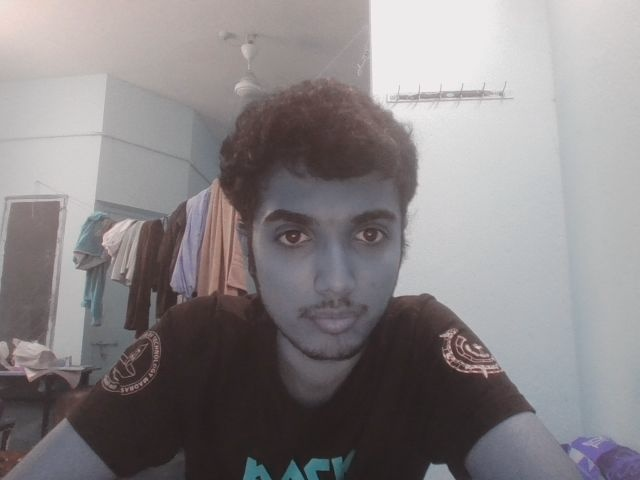

In [53]:
img

In [54]:
with open(os.path.join('data', 'train', 'labels', '10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.json'), 'r') as f:
  label =json.load(f)

In [55]:
label['shapes'][0]['points']

[[174.54545454545456, 83.18181818181824],
 [456.3636363636364, 369.54545454545473]]

In [56]:
coords = [0,0,0,0]

coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [57]:
coords

[174.54545454545456, 83.18181818181824, 456.3636363636364, 369.54545454545473]

In [58]:
coords = list(np.divide(coords, [640,480,640,480]))

In [59]:
coords

[np.float64(0.27272727272727276),
 np.float64(0.17329545454545467),
 np.float64(0.7130681818181819),
 np.float64(0.769886363636364)]

In [60]:
augmented = augmentor(image = img, bboxes = [coords], class_labels=['face'])

In [62]:
type(augmented)

dict

In [66]:
augmented['bboxes']

[[0.0, 0.17151515007019044, 0.6254545338948567, 0.8078787994384765]]

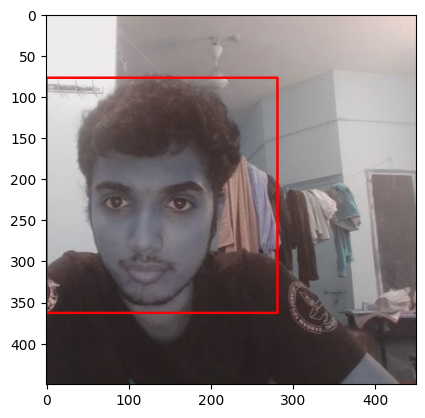

In [67]:
#drawing rectangle
cv2.rectangle(augmented['image'],
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)),
                    (255,0,0), 2)
plt.imshow(augmented['image'])
